# 第4章: 言語解析

問題30から問題35までは、以下の文章`text`（太宰治の『走れメロス』の冒頭部分）に対して、言語解析を実施せよ。問題36から問題39までは、国家を説明した文書群（日本語版ウィキペディア記事から抽出したテキスト群）をコーパスとして、言語解析を実施せよ。

In [7]:
text = """
メロスは激怒した。
必ず、かの邪智暴虐の王を除かなければならぬと決意した。
メロスには政治がわからぬ。
メロスは、村の牧人である。
笛を吹き、羊と遊んで暮して来た。
けれども邪悪に対しては、人一倍に敏感であった。
"""

## 30. 動詞
文章`text`に含まれる動詞をすべて表示せよ。

In [8]:
!pip install mecab-python3 unidic-lite

In [9]:
""" リファレンス: https://zenn.dev/robes/articles/e17e298d0b0b9a """
# 形態素分析ライブラリーMeCab と 辞書(mecab-ipadic-NEologd)のインストール
!apt-get install mecab libmecab-dev mecab-ipadic-utf8 git make curl xz-utils file -y
!apt-get -q -y install sudo file mecab libmecab-dev mecab-ipadic-utf8 git curl xz-utils make python-mecab > /dev/null
!git clone --depth 1 https://github.com/neologd/mecab-ipadic-neologd.git > /dev/null
!echo yes | mecab-ipadic-neologd/bin/install-mecab-ipadic-neologd -n > /dev/null 2>&1
!pip install mecab-python3 > /dev/null

# シンボリックリンクによるエラー回避
!ln -s /etc/mecabrc /usr/local/etc/mecabrc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libmecab-dev is already the newest version (0.996-14build9).
make is already the newest version (4.3-4.1build1).
mecab-ipadic-utf8 is already the newest version (2.7.0-20070801+main-3).
xz-utils is already the newest version (5.2.5-2ubuntu1).
mecab is already the newest version (0.996-14build9).
curl is already the newest version (7.81.0-1ubuntu1.20).
file is already the newest version (1:5.41-3ubuntu0.1).
git is already the newest version (1:2.34.1-1ubuntu1.15).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
E: Unable to locate package python-mecab
fatal: destination path 'mecab-ipadic-neologd' already exists and is not an empty directory.
ln: failed to create symbolic link '/usr/local/etc/mecabrc': File exists


In [10]:
!echo `mecab-config --dicdir`"/mecab-ipadic-neologd"

/usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd


In [11]:
import MeCab
import re

In [12]:
mecab = MeCab.Tagger('-d /usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd') # タグをつけてくれる？

sentences = re.split('\n', text)
words = []
for sentence in sentences:
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    # print(line)
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    # print(word, feature)
    features = feature.split(',')
    # print(features[0])
    if features[0] == '動詞':
      words.append(word)

print(words)

['し', '除か', 'なら', 'し', 'わから', '吹き', '遊ん', '暮し', '来']


## 31. 動詞の原型
文章`text`に含まれる動詞と、その原型をすべて表示せよ。

In [13]:
mecab = MeCab.Tagger('-d /usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd') # タグをつけてくれる？

sentences = re.split('\n', text)
words_lemma = {}
for sentence in sentences:
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    # print(line)
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    # print(word, feature)
    features = feature.split(',')
    # print(word, features)
    if features[0] == '動詞':
      words_lemma[word] = features[-3]

for w, l in words_lemma.items():
  print(f'動詞: {w}, 原型: {l}')

動詞: し, 原型: する
動詞: 除か, 原型: 除く
動詞: なら, 原型: なる
動詞: わから, 原型: わかる
動詞: 吹き, 原型: 吹く
動詞: 遊ん, 原型: 遊ぶ
動詞: 暮し, 原型: 暮す
動詞: 来, 原型: 来る


## 32. 「AのB」
文章`text`において、2つの名詞が「の」で連結されている名詞句をすべて抽出せよ。

In [14]:
mecab = MeCab.Tagger('-d /usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd') # タグをつけてくれる？

sentences = re.split('\n', text)
noun_phrase = []
noun_flag = False
no_flag = False
compose = ''
for sentence in sentences:
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    # print(line)
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    # print(word, feature)
    features = feature.split(',')
    # print(word, features)
    if features[0] == '名詞' and noun_flag == False: # 名詞が初めて来た
      noun_flag = True
      compose += word
    elif noun_flag == True and word == 'の': # 直前が名詞で今回が「の」
      no_flag = True
      compose += word
    elif noun_flag == True and no_flag == True and features[0] == '名詞':
      compose += word
      noun_phrase.append(compose)
      compose = compose
      no_flag = False
    elif noun_flag == True and features[0] == '名詞':
      compose += compose
    else:
      noun_flag = False
      no_flag = False
      compose = ""
print(noun_phrase)

['邪智邪智の王', '村の牧人']


## 33. 係り受け解析

文章`text`に係り受け解析を適用し、係り元と係り先のトークン（形態素や文節などの単位）をタブ区切り形式ですべて抽出せよ。

In [15]:
!pip install -U ginza ja_ginza

In [16]:
import spacy
import re
import pandas as pd

In [17]:
nlp = spacy.load('ja_ginza')

In [18]:
data = {'係り元': [], '係り先': []}
sentences = re.split('\n', text)
for sentence in sentences:
  doc = nlp(sentence)
  for token in doc:
    data['係り元'].append(doc[token.i])
    data['係り先'].append(doc[token.head.i])
    # print(token.i, token.text, token.dep_, token.head.i)
df = pd.DataFrame(data)
df

,係り元,係り先
0,メロス,激怒
1,は,メロス
2,激怒,激怒
3,し,激怒
4,た,激怒
...,...,...
65,敏感,敏感
66,で,敏感
67,あっ,で
68,た,敏感


## 34. 主述の関係
文章`text`において、「メロス」が主語であるときの述語を抽出せよ。

In [19]:
doc = nlp(text)
tokens = []
for sent in doc.sents:
  for token in sent: # トークン(単語)を格納
    tokens.append(token)
  subject_list = []
  for token in tokens:
    ## 依存関係ラベルがnsubj=>「＜見出し語＞:＜係り先の見出し語＞」をリストに追加する。
    if token.dep_ in ["nsubj", "iobj"]: # nsubj = 主語, iobj = 間接目的語
      subject_list.append(f"{token.lemma_} : {tokens[token.head.i].lemma_}")
print(subject_list)

['メロス : 激怒', '政治 : わかる', 'メロス : 牧人']


## 35. 係り受け木
「メロスは激怒した。」の係り受け木を可視化せよ。

In [20]:
from spacy import displacy

In [21]:
sentence = "メロスは激怒した。"
doc = nlp(sentence)
displacy.render(doc, style = "dep", options = {"compact": True})

## 36. 単語の出現頻度

問題36から39までは、Wikipediaの記事を以下のフォーマットで書き出したファイル[jawiki-country.json.gz](/data/jawiki-country.json.gz)をコーパスと見なし、統計的な分析を行う。

* 1行に1記事の情報がJSON形式で格納される
* 各行には記事名が"title"キーに、記事本文が"text"キーの辞書オブジェクトに格納され、そのオブジェクトがJSON形式で書き出される
* ファイル全体はgzipで圧縮される

まず、第3章の処理内容を参考に、Wikipedia記事からマークアップを除去し、各記事のテキストを抽出せよ。そして、コーパスにおける単語（形態素）の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [22]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [23]:
import re
import json
import collections # https://note.nkmk.me/python-collections-counter/

In [24]:
def remove_markup(text):
  text = re.sub("'+", '', text) # 強調マークアップの除去
  text = re.sub('\{\{(.*?)\s+?icon\}\}', '', text) # {{xxx icon}}の場合を除去
  text = re.sub('\{\{lang\|.*?\|(.+?)\}\}', r'\1', text) # {{lang|xxx|yyy}}のyyyのみを取得
  text = re.sub('\{\{lang.*?\|(.+?)\}\}', r'\1', text) # {{lang|xxx}}のxxxのみを取得
  text = re.sub('\{\{仮リンク\|(.*?)\|(.+?)\}\}', r'\1', text) # {{仮リンク|xxx|yyy~}}のxxxのみを取得
  text = re.sub('\{\{([^|]+?)\}\}', r'\1', text) # {{xxx}}内でxxx内に|が含まれていない場合の{{}}の除去
  text = re.sub('\{\{(.+?)\|(.+?)\}\}', r'\2', text) # {{xxx|yyy}}のyyyのみを取得
  text = re.sub('=[=]+', '', text) # 見出しの除去
  text = re.sub('\[\[Category:(.+?)\|.*?\]\]', r'\1', text) # カテゴリの除去
  text = re.sub('\[\[Category:(.+?)\]\]', r'\1', text) # カテゴリの除去
  text = re.sub('\[\[(?:ファイル):(.+?\|)*(.+?)\]\]', r'\2', text) # ファイルの除去
  text = re.sub('\[\[(?:File|file):(.+?\|)*(.+?)\]\]', r'\2', text) # ファイルの除去
  text = re.sub('(?:ファイル):(.+?\|)*(.+?)', r'\2', text) # ファイルの除去
  text = re.sub('\*+\s*?(.+?)', r'\1', text) # 箇条書きの除去
  text = re.sub('#+\s*?(.+?)', r'\1', text) # 番号付き箇条書きの除去
  text = re.sub(';\s*?(.+?)', r'\1', text) # 定義の箇条書きの除去
  text = re.sub(':\s*?(.+?)', r'\1', text) # 定義の箇条書きの除去
  text = re.sub('\[\[([^|]+?)\]\]', r'\1', text) # [[xxx]]内でxxx内に|が含まれていない場合の[[]]の除去
  text = re.sub('\[\[(.*?)\|(.+?)\]\]', r'\2', text) # 内部リンクの除去
  text = re.sub('\[http.*? (.+?)\]', r'\1', text) # 外部リンクの除去 [http~ xxx]の場合
  text = re.sub('\[http.*?\]', '', text) # 外部リンクの除去 [http~]の場合
  text = re.sub('\|(.*?)', r'\1', text)
  text = re.sub('http.*', '', text)
  text = re.sub('\[\[(.*?)\]\]', r'\1', text)
  text = re.sub('<ref>|</ref>|<ref.+?/>', '', text)
  text = re.sub('<ref .*?>', '', text)
  text = re.sub('{{|}}|[[|]]', '', text)
  return text

In [25]:
data_list = []
with open('/content/drive/MyDrive/nlp100/lesson04/jawiki-country.json') as file:
  for line in file:
    data_list.append(json.loads(line))

data_list2 = []
for data in data_list:
  data_list2.append({'title': data['title'], 'text': remove_markup(data['text'])})

In [26]:
mecab = MeCab.Tagger('-d /usr/lib/x86_64-linux-gnu/mecab/dic/mecab-ipadic-neologd')

words = []
for data in data_list2:
  sentence = data['text']
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    words.append(word)
counter = collections.Counter(words)
counter.most_common(20)

[('の', 87242),
 ('、', 82745),
 ('は', 49132),
 ('。', 48874),
 ('に', 47004),
 ('が', 41972),
 ('を', 36737),
 ('た', 33402),
 ('で', 32076),
 ('=', 27504),
 ('と', 26335),
 ('て', 24136),
 ('し', 23871),
 ('）', 18059),
 ('（', 17633),
 ('れ', 13269),
 ('いる', 12609),
 ('さ', 12297),
 ('-', 11977),
 ('ある', 11143)]

## 37. 名詞の出現頻度
コーパスにおける名詞の出現頻度を求め、出現頻度の高い20語とその出現頻度を表示せよ。

In [27]:
words = []
for data in data_list2:
  sentence = data['text']
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    features = feature.split(',')
    if features[0] == '名詞':
      words.append(word)
counter = collections.Counter(words)
counter.most_common(20)

[('こと', 4325),
 ('1', 3440),
 ('ため', 3111),
 ('日本', 2864),
 ('人', 2797),
 ('2', 2624),
 ('的', 2622),
 ('GDP', 2405),
 ('大統領', 2299),
 ('国', 2218),
 ('独立', 2149),
 ('url', 2124),
 ('br', 2088),
 ('人口', 2073),
 ('現在', 1763),
 ('世界', 1762),
 ('title', 1707),
 ('地域', 1703),
 ('of', 1657),
 ('4', 1649)]

## 38. TF・IDF
日本に関する記事における名詞のTF・IDFスコアを求め、TF・IDFスコア上位20語とそのTF, IDF, TF・IDFを表示せよ。

In [37]:
from collections import Counter
import math

In [29]:
vocab = set()
docs = list()
for data in data_list2:
  nouns = [] # 記事で存在する名詞
  sentence = data['text']
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    features = feature.split(',')
    if features[0] == '名詞':
      vocab.add(word)
      nouns.append(word)
  docs.append(nouns)

In [73]:
vocab_list = sorted(list(vocab))
word_to_idx = {word: i for i, word in enumerate(vocab_list)}
idx_tp_word = {i: word for i, word in enumerate(vocab_list)}
vocab_size = len(vocab_list)

bow_model = []
for i, doc in enumerate(docs):
  counts = Counter(doc)
  freq = [0] * vocab_size
  for noun, count in counts.items(): # docにはnounがcountだけ存在
    if noun in word_to_idx:
      freq[word_to_idx[noun]] = count # freq[nounが登録されているインデックス] = count
  bow_model.append(freq)

In [74]:
def SearchDocumentsIncludeQuery(bag_of_words_model, index):
  docs_idx = list()
  for i in range(len(bag_of_words_model)):
    doc = bag_of_words_model[i]
    if doc[index] != 0:
      docs_idx.append(i)
  return docs_idx

def TermFrequency(bag_of_words_model, article_idx):
  M = sum(bag_of_words_model[article_idx])
  tf = bag_of_words_model[article_idx]
  for i in range(len(tf)):
    tf[i] /= M
  return tf

def DocumentFrequency(bag_of_words_model, index):
  total = 0
  for doc in bag_of_words_model:
    if doc[index] != 0:
      total += 1
  return total

def InverseDocumentFrequency(bag_of_words_model, index):
  N = len(bag_of_words_model)
  df = DocumentFrequency(bag_of_words_model, index)
  return math.log10(N / df)

In [78]:
query = '日本'
index = word_to_idx[query]

data_ja_idx = 0
for i in range(len(data_list2)):
  data = data_list2[i]
  if data['title'] == query:
    data_ja_idx = i
    break

tf_idf_list = []
tf_ja = TermFrequency(bow_model, data_ja_idx)
for i in range(len(tf_ja)):
  tf = tf_ja[i]
  idf = InverseDocumentFrequency(bow_model, i)
  tf_idf_list.append(tf * idf)

tf_idf = {idx_tp_word[i]: tf_idf for i, tf_idf in enumerate(tf_idf_list)}
tf_idf = sorted(tf_idf.items(), key = lambda item: item[1], reverse = True)[:20]

In [79]:
import pandas as pd

In [80]:
data = {'noun': [], 'TF': [], 'IDF': [], 'TF-IDF': []}
for ele in tf_idf:
  idf = InverseDocumentFrequency(bow_model, word_to_idx[ele[0]])
  data['noun'].append(ele[0])
  data['TF-IDF'].append(ele[1])
  data['TF'].append(ele[1] / idf)
  data['IDF'].append(idf)
df = pd.DataFrame(data)
df

,noun,TF,IDF,TF-IDF
0,div,0.006482,1.190332,0.007715
1,pxheight,0.002973,1.917330,0.005699
2,Times New Roman,0.001899,2.394452,0.004547
3,aligncenterfont,0.001899,2.394452,0.004547
4,倭国,0.001610,2.394452,0.003855
5,pt,0.002931,1.248324,0.003659
6,日本国憲法,0.001321,2.394452,0.003163
7,倭,0.001404,2.093422,0.002938
8,天皇,0.001940,1.440209,0.002795
9,Meiryo,0.001032,2.394452,0.002471


## 39. Zipfの法則
コーパスにおける単語の出現頻度順位を横軸、その出現頻度を縦軸として、両対数グラフをプロットせよ。

In [81]:
from collections import Counter
import matplotlib.pyplot as plt

In [88]:
words = []
for data in data_list2:
  sentence = data['text']
  parsed = mecab.parse(sentence)
  for line in parsed.splitlines():
    if line == 'EOS':
      break
    word, feature = line.split('\t')
    words.append(word)
counts = collections.Counter(words)

In [89]:
data = {'rank': [], 'freq': []}
counts = counts.most_common()
for i, ele in enumerate(counts):
  data['rank'].append(i)
  data['freq'].append(ele[1])
df = pd.DataFrame(data)
df

,rank,freq
0,0,87242
1,1,82745
2,2,49132
3,3,48874
4,4,47004
...,...,...
98576,98576,1
98577,98577,1
98578,98578,1
98579,98579,1


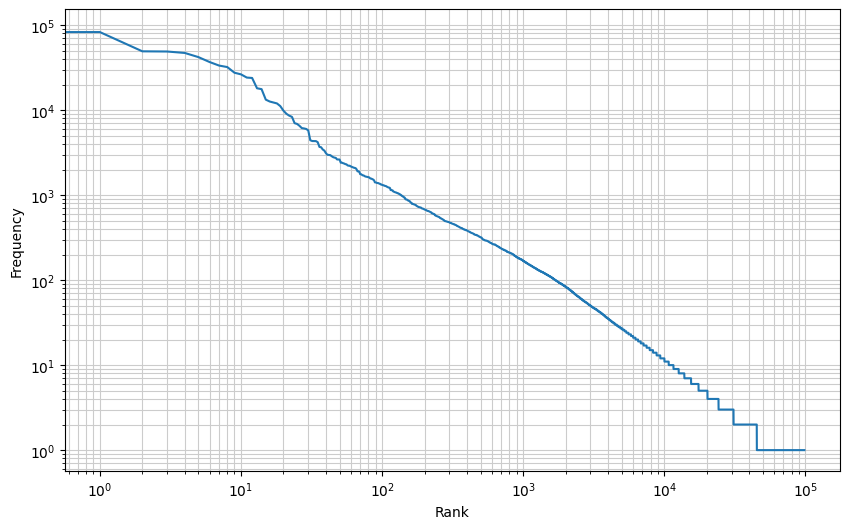

In [93]:
plt.figure(figsize = (10, 6))
plt.plot(df['rank'], df['freq'], linestyle = '-')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.grid(True, which = "both", ls = "-", color = '0.8')